# Practice 2.
## Guillem Moreno Garcia
##  Objectives:
1. Learn to clean data with pandas.

2. Do a simple Linear regression

## Aplication:
Data basse: Data set from the UCI Machine Learning Repository
(http://archive.ics.uci.edu/ml)
1.   Cars data: http://archive.ics.uci.edu/ml/datasets/Automobile.
- Predict **price** in dollars.

2. Database: Wine quality, http://archive.ics.uci.edu/ml/datasets/Wine+Quality
- Predict **quality** (score between 0 and 10)


___________________________________

## First we load the Libraries
* Pandas: For dealing with tabulated data: excel + sql
* sklearn: Machine learning framework
* os: anciliary functions for dealing with the operating system

In [2]:
import pandas as pd
import os 

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import sklearn

### Use the os library for generating the path to the file

In [4]:
File = "Bdcars.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')

Filename with path: 
 c:\mlearn-lab\SecondPractice\Data\Bdcars.csv


### First rows of the file
**make, fuel-type, aspiration, num-of-doors, body-style, drive-wheels, engine-location, wheel-base, length, width, height, curb-weight, engine-type, num-of-cylinders, engine-size, fuel-system, bore, stroke, compression-ratio, horsepower, peak-rpm, city-mpg, highway-mpg, price**

alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495

alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111,5000,21,27,16500

alfa-romero,gas,std,two,hatchback,rwd,front,94.50,171.20,65.50,52.40,2823,ohcv,six,152,mpfi,2.68,3.47,9.00,154,5000,19,26,16500

### Load the data by means of Pandas
- Note that the structure is a csv: Comma separated values
- The library recognizes the first line as the name of the columns
- Note the similarity with an *excel file*

#  See Appendix for  the meaning of the variables.

In [5]:
Data = pd.read_csv(Filename)
Data.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [6]:
print(f'Size of the database: {Data.shape} (rows X columns)')

Size of the database: (205, 24) (rows X columns)


## Next we get general information about the dataframe
## Dtype -> will allow to see which transformations should be done

In [7]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0    make               205 non-null    object 
 1    fuel-type          205 non-null    object 
 2    aspiration         205 non-null    object 
 3    num-of-doors       205 non-null    object 
 4    body-style         205 non-null    object 
 5    drive-wheels       205 non-null    object 
 6    engine-location    205 non-null    object 
 7    wheel-base         205 non-null    float64
 8    length             205 non-null    float64
 9    width              205 non-null    float64
 10   height             205 non-null    float64
 11   curb-weight        205 non-null    int64  
 12   engine-type        205 non-null    object 
 13   num-of-cylinders   205 non-null    object 
 14   engine-size        205 non-null    int64  
 15   fuel-system        205 non-null    object 
 16   bore   

## First we clean the price feature
###  We erraise the unknowns '?'

In [8]:
Data =Data[Data[' price'] != '?']
Data[' price'] = Data[' price'].astype('float')
print('*'*30)
print('Shape of the data: ',Data.shape)
print('*'*30)
Data.info()

******************************
Shape of the data:  (201, 24)
******************************
<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 0 to 204
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0    make               201 non-null    object 
 1    fuel-type          201 non-null    object 
 2    aspiration         201 non-null    object 
 3    num-of-doors       201 non-null    object 
 4    body-style         201 non-null    object 
 5    drive-wheels       201 non-null    object 
 6    engine-location    201 non-null    object 
 7    wheel-base         201 non-null    float64
 8    length             201 non-null    float64
 9    width              201 non-null    float64
 10   height             201 non-null    float64
 11   curb-weight        201 non-null    int64  
 12   engine-type        201 non-null    object 
 13   num-of-cylinders   201 non-null    object 
 14   engine-size       

## Next we deal with the categorical data.
###  Get the unique data, observe the return object is a Numpy Array of objects (strings)
###  Note: This can be done in a more straight forward way, but  the idea is to get used with the basics of pandas.

In [9]:
NamesMake = Data[' make'].unique()
print(NamesMake)

['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']


###  We create a code for each of the makes.
**NOTE**:  Categorical features, there is no order. 
**SOLUTION**: Will be given in decision trees.

### We use an implementation of 'dict comprehension' and '.map()'

In [10]:
CodeMake = list(range(len(NamesMake)))

MappingName2code = {key:float(val) for (key,val)  in zip(NamesMake,CodeMake)}
print(MappingName2code)

{'alfa-romero': 0.0, 'audi': 1.0, 'bmw': 2.0, 'chevrolet': 3.0, 'dodge': 4.0, 'honda': 5.0, 'isuzu': 6.0, 'jaguar': 7.0, 'mazda': 8.0, 'mercedes-benz': 9.0, 'mercury': 10.0, 'mitsubishi': 11.0, 'nissan': 12.0, 'peugot': 13.0, 'plymouth': 14.0, 'porsche': 15.0, 'renault': 16.0, 'saab': 17.0, 'subaru': 18.0, 'toyota': 19.0, 'volkswagen': 20.0, 'volvo': 21.0}


In [11]:
Data[' make'].map(MappingName2code)

0       0.0
1       0.0
2       0.0
3       1.0
4       1.0
       ... 
200    21.0
201    21.0
202    21.0
203    21.0
204    21.0
Name:  make, Length: 201, dtype: float64

In [12]:
Data[' make'] = Data[' make'].map(MappingName2code)
Data.T.head()

,0,1,2,3,4,5,6,7,8,10,...,195,196,197,198,199,200,201,202,203,204
make,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,...,21.0,21.0,21.0,21.0,21.0,21.0,21.0,21.0,21.0,21.0
fuel-type,gas,gas,gas,gas,gas,gas,gas,gas,gas,gas,...,gas,gas,gas,gas,gas,gas,gas,gas,diesel,gas
aspiration,std,std,std,std,std,std,std,std,turbo,std,...,std,std,std,turbo,turbo,std,turbo,std,turbo,turbo
num-of-doors,two,two,two,four,four,two,four,four,four,two,...,four,four,four,four,four,four,four,four,four,four
body-style,convertible,convertible,hatchback,sedan,sedan,sedan,sedan,wagon,sedan,sedan,...,wagon,sedan,wagon,sedan,wagon,sedan,sedan,sedan,sedan,sedan


 ### Exercise: <font color='red'>Correct all the categorical fields </font>
 Note: In case there is an order, such as **num-of-doors** make a coding that follows the order.

In [13]:
# Correcting categorical fields and cleaning '?'
for col in [' bore', ' stroke', ' horsepower', ' peak-rpm']:
    Data = Data[Data[col] != '?']
    Data[col] = Data[col].astype('float')

doors_map = {'two': 2, 'four': 4}
cylinders_map = {'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12}

Data[' num-of-doors'] = Data[' num-of-doors'].map(doors_map)
Data[' num-of-cylinders'] = Data[' num-of-cylinders'].map(cylinders_map)

# Integer mapping for nominal fields (label encoding)
nominal_cols = [' fuel-type', ' aspiration', ' body-style', ' drive-wheels', ' engine-location', ' engine-type', ' fuel-system']
for col in nominal_cols:
    Data[col] = Data[col].astype('category').cat.codes.astype(float)

# In case some rows have NaNs after mapping
Data = Data.dropna()
Data = Data.astype(float)

cols2drop = [] # No columns dropped because all were corrected


 ### Next we will eraise the columns that have not been corrected.
 ### Also will correct the integers to floats.

In [14]:
Data.columns

Index([' make', ' fuel-type', ' aspiration', ' num-of-doors', ' body-style',
       ' drive-wheels', ' engine-location', ' wheel-base', ' length', ' width',
       ' height', ' curb-weight', ' engine-type', ' num-of-cylinders',
       ' engine-size', ' fuel-system', ' bore', ' stroke',
       ' compression-ratio', ' horsepower', ' peak-rpm', ' city-mpg',
       ' highway-mpg', ' price'],
      dtype='object')

In [15]:
TypeOfColumn = Data.dtypes
print(TypeOfColumn)

make                 float64
fuel-type            float64
aspiration           float64
num-of-doors         float64
body-style           float64
drive-wheels         float64
engine-location      float64
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight          float64
engine-type          float64
num-of-cylinders     float64
engine-size          float64
fuel-system          float64
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg             float64
highway-mpg          float64
price                float64
dtype: object


In [16]:
cols2drop = list()
for col,dtype in zip(Data.columns,TypeOfColumn):
    print(f' Name of columns:{col}   \t||| Type of column: {dtype}')
    if dtype == 'object':
        cols2drop.append(col)

 Name of columns: make   	||| Type of column: float64
 Name of columns: fuel-type   	||| Type of column: float64
 Name of columns: aspiration   	||| Type of column: float64
 Name of columns: num-of-doors   	||| Type of column: float64
 Name of columns: body-style   	||| Type of column: float64
 Name of columns: drive-wheels   	||| Type of column: float64
 Name of columns: engine-location   	||| Type of column: float64
 Name of columns: wheel-base   	||| Type of column: float64
 Name of columns: length   	||| Type of column: float64
 Name of columns: width   	||| Type of column: float64
 Name of columns: height   	||| Type of column: float64
 Name of columns: curb-weight   	||| Type of column: float64
 Name of columns: engine-type   	||| Type of column: float64
 Name of columns: num-of-cylinders   	||| Type of column: float64
 Name of columns: engine-size   	||| Type of column: float64
 Name of columns: fuel-system   	||| Type of column: float64
 Name of columns: bore   	||| Type of col

In [17]:
print(cols2drop)

[]


In [18]:
Data.drop(cols2drop,axis = 1).T

,0,1,2,3,4,5,6,7,8,10,...,195,196,197,198,199,200,201,202,203,204
make,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,2.0,...,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00
fuel-type,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00
aspiration,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.0,...,0.00,0.00,0.00,1.00,1.00,0.00,1.00,0.00,1.00,1.00
num-of-doors,2.00,2.00,2.00,4.00,4.00,2.00,4.00,4.00,4.00,2.0,...,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00
body-style,0.00,0.00,2.00,3.00,3.00,3.00,3.00,4.00,3.00,3.0,...,4.00,3.00,4.00,3.00,4.00,3.00,3.00,3.00,3.00,3.00
drive-wheels,2.00,2.00,2.00,1.00,0.00,1.00,1.00,1.00,1.00,2.0,...,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00
engine-location,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
wheel-base,88.60,88.60,94.50,99.80,99.40,99.80,105.80,105.80,105.80,101.2,...,104.30,104.30,104.30,104.30,104.30,109.10,109.10,109.10,109.10,109.10
length,168.80,168.80,171.20,176.60,176.60,177.30,192.70,192.70,192.70,176.8,...,188.80,188.80,188.80,188.80,188.80,188.80,188.80,188.80,188.80,188.80
width,64.10,64.10,65.50,66.20,66.40,66.30,71.40,71.40,71.40,64.8,...,67.20,67.20,67.20,67.20,67.20,68.90,68.80,68.90,68.90,68.90


In [19]:
Data = Data.drop(cols2drop,axis = 1)


## Before doing the linear regression analize the scatter plots


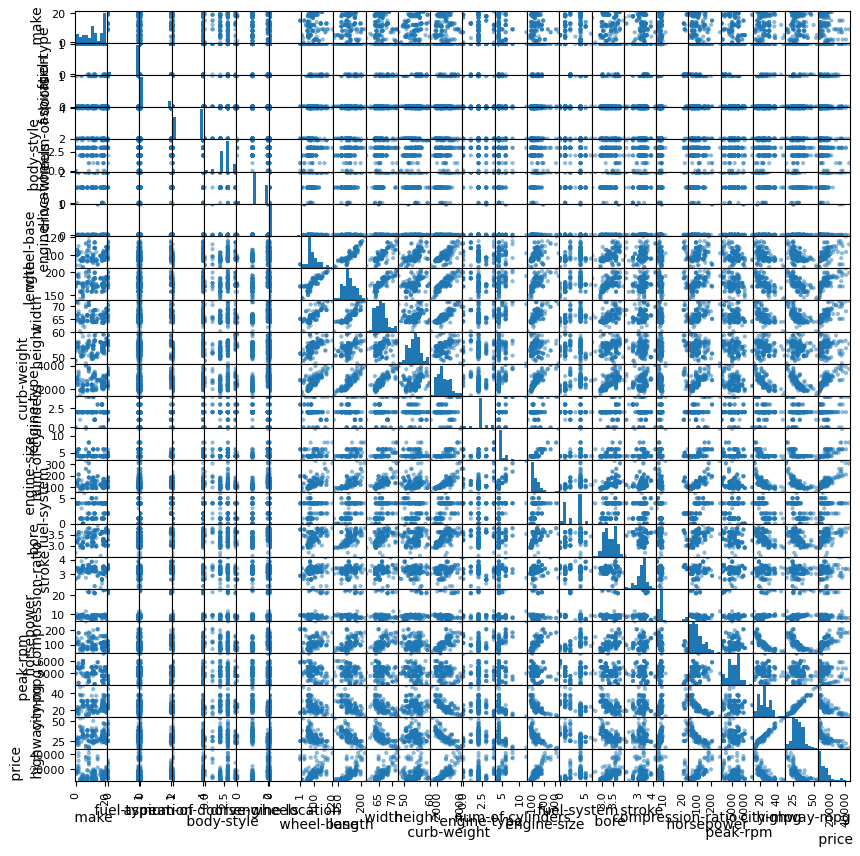

In [20]:
ax = pd.plotting.scatter_matrix(Data,figsize = (10,10))

### Exercise 
1. <font color='red'> Relate price (target) to a subset of features </font>
2. <font color='red'> Relate  subset of features ' city-mpg',' length',' engine-size' between themselves </font>

* In theory we will explain why it is usefull, but first try to understand

In [21]:
print(Data.columns.values)

[' make' ' fuel-type' ' aspiration' ' num-of-doors' ' body-style'
 ' drive-wheels' ' engine-location' ' wheel-base' ' length' ' width'
 ' height' ' curb-weight' ' engine-type' ' num-of-cylinders'
 ' engine-size' ' fuel-system' ' bore' ' stroke' ' compression-ratio'
 ' horsepower' ' peak-rpm' ' city-mpg' ' highway-mpg' ' price']


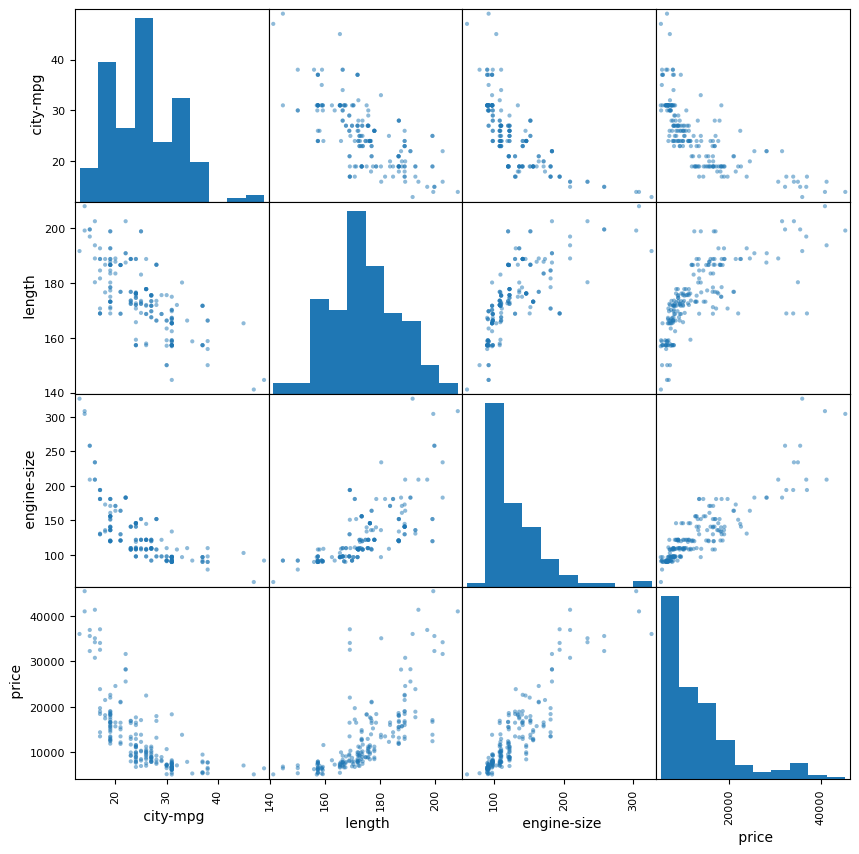

In [22]:
ax = pd.plotting.scatter_matrix(Data[[' city-mpg',' length',' engine-size',' price']],figsize = (10,10))

### Excercise 
1. <font color='red'> Explain in words, why correlation between input variables is bad, but with the output is good. </font>


 ## Now we will make a model that predicts the price given the features
 ###  Note that it will be a linear model. 
 
 * The scatter plot indicates that possibly we could use second order polynomials for fitting, but we have freedom for deciding the model.
 * There are other considerations for prefering a **linear model**.
 ###  First we create the database.

In [23]:
Input = Data[[' make', ' wheel-base' ,' length', ' width' ,' height', ' curb-weight',
 ' engine-size', ' compression-ratio', ' city-mpg', ' highway-mpg']]
Price = Data[[' price']]

### Next we estimate the parameters by **min squares**

In [24]:
from sklearn import linear_model
CarPrice = linear_model.LinearRegression()
CarPrice.fit (Input, Price)

print(CarPrice.coef_)
print(CarPrice.intercept_)

[[-140.63962856 -137.33578327  -40.70842587  696.97055214  397.94315481
     1.8924523   126.74274452  156.76539746 -428.78843721  261.12632032]]
[-51506.16714637]


In [25]:
print(Input.columns)

Index([' make', ' wheel-base', ' length', ' width', ' height', ' curb-weight',
       ' engine-size', ' compression-ratio', ' city-mpg', ' highway-mpg'],
      dtype='object')


In [26]:
df_car_coef = pd.DataFrame(CarPrice.coef_,columns = Input.columns)
df_car_coef

,make,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
0,-140.639629,-137.335783,-40.708426,696.970552,397.943155,1.892452,126.742745,156.765397,-428.788437,261.12632


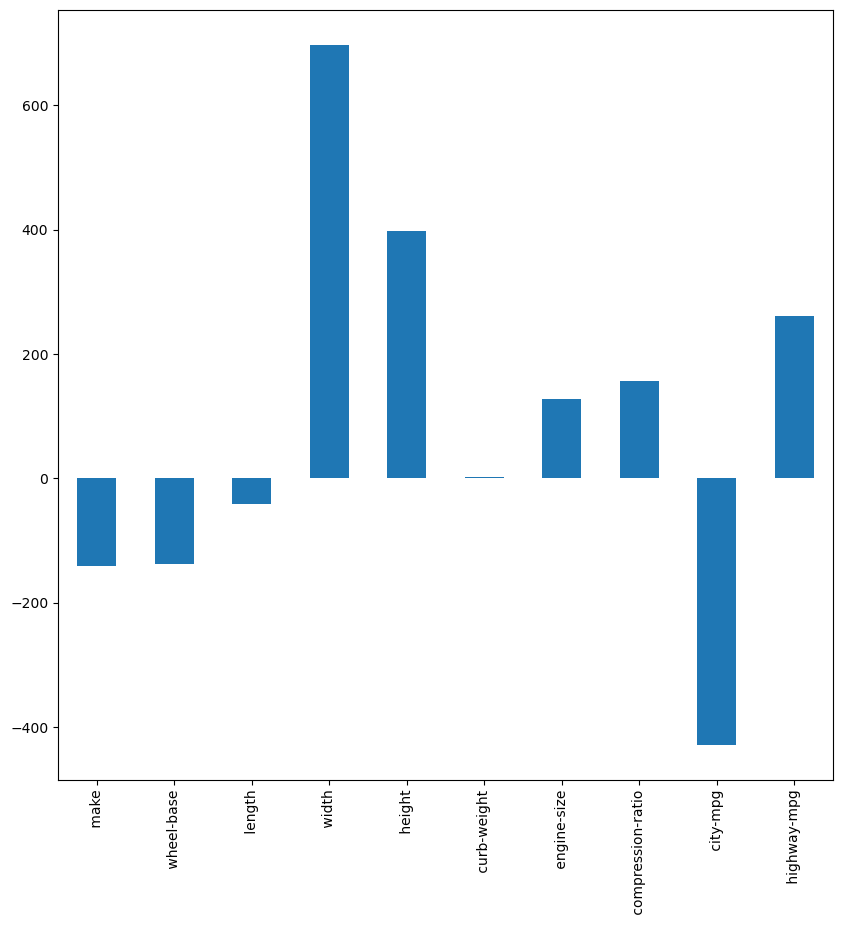

In [27]:
_ = df_car_coef.T.plot(kind = 'bar',figsize = (10,10),legend = False)


### Excercise 
1. <font color='red'> Explain in words, the meaning of each of the values of the weights. What sense do they have? </font>

2. <font color='red'> If collecting a database is expensive, what recommendation would you give? </font>


## We will see how it works over the training database.
### Note that the correct way is to use a validation database, which we will see below

In [28]:
PredictedPrice  = CarPrice.predict(Input)

### Scatter plot. 
* Ideal relationship should be linear

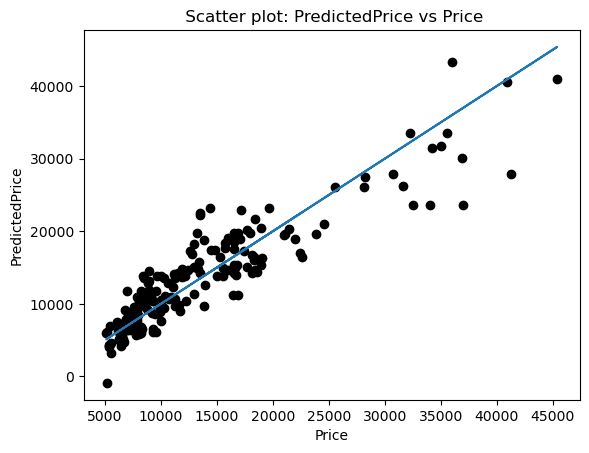

In [29]:
plt.scatter(Price, PredictedPrice,   color='black')
plt.title(' Scatter plot: PredictedPrice vs Price')
plt.plot(Price,Price)
plt.xlabel('Price')
plt.ylabel('PredictedPrice')
plt.show()

## Performance of the model on the training database

* Mean squared error:   
 $\text{MSE}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (y_i - \hat{y}_i)^2.$
* Explained variance ($R^2$):   
$R^2(y, \hat{y}) = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$

In [30]:
from sklearn.metrics import mean_squared_error
print (f'MSE = {mean_squared_error(Price, PredictedPrice):2.2f} ')
print (f'Root MSE = {np.sqrt(mean_squared_error(Price, PredictedPrice)):2.2f} ')

MSE = 10570057.80 
Root MSE = 3251.16 


In [31]:
from sklearn.metrics import r2_score
print (f'Explained Variance: $r^2$ = {r2_score(Price, PredictedPrice)*100.:2.2f} %')

Explained Variance: $r^2$ = 83.76 %


### Excercise 
1. <font color='red'> Explain in words, why r^2 is more usefull than MSE. </font>




**Why R^2 is more useful than MSE:**  
While Mean Squared Error (MSE) provides an absolute measure of prediction error in the units of the target variable squared, it is highly dependent on the scale of the dataset. Therefore, it is difficult to judge whether a particular MSE is 'good' or 'bad' without context.  
On the other hand, the Explained Variance ($R^2$) normalizes the error, providing a relative score between 0 and 1 (or 0% to 100%). It represents the proportion of variance in the target variable that is explained by the model, making it much easier to interpret and comparable across different datasets and target ranges.

##  Need for Cross-validation

###  Definition
Cross-validation is a statistical technique used in machine learning to evaluate how well a model generalizes to independent datasets.

1. It consists of dividing the training dataset into several parts, or folds, typically between 5 and 10 (See figure below).
<img src="EsquemaValidacioCreuada.png" width="60%">

2. One of the folds is reserved as a test set, while the rest are used to train the model. This process is repeated as many times as there are folds, so that each part of the dataset acts as a test set once.

3. Utility of validation:
   1. Detects overfitting, i.e., when a model adapts too much to the specific details of the training data and does not perform well with new examples.
   2. Through cross-validation, one can **better adjust the model parameters** to achieve a balance between fitting the training data and the ability to generalize.
   3. Allows creating more robust and reliable models, increasing confidence in the predictions made by these models in real-world situations.

In [32]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

# Set up 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Compute MSE using cross-validation (negative because sklearn uses negative MSE)
mse_scores = -cross_val_score(CarPrice, Input, Price, cv=kfold, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(mse_scores)

# Compute R^2 using cross-validation
r2_scores = cross_val_score(CarPrice, Input, Price, cv=kfold, scoring='r2')

# Display results
print("Cross-Validation Results (5-Fold):")
print(f"MSE scores: {mse_scores}")
print(f"Mean MSE: {mse_scores.mean():.2f} (+/- {mse_scores.std():.2f})")
print(f"\nRMSE scores: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean():.2f} (+/- {rmse_scores.std():.2f})")
print(f"\nR^2 scores: {r2_scores}")
print(f"Mean R^2: {r2_scores.mean()*100:.2f}% (+/- {r2_scores.std()*100:.2f}%)")

Cross-Validation Results (5-Fold):
MSE scores: [17730790.36819898 12355085.35594819 10734583.33234895 11636279.40505602
 10035144.6545546 ]
Mean MSE: 12498376.62 (+/- 2732045.98)

RMSE scores: [4210.79450558 3514.98013593 3276.36739887 3411.19911542 3167.82964418]
Mean RMSE: 3516.23 (+/- 366.71)

R^2 scores: [0.84221754 0.5980051  0.86765469 0.77470281 0.78217261]
Mean R^2: 77.30% (+/- 9.43%)


 ### Exercise: <font color='red'> Create an infographic for the work done </font>
1. Explain in words, why the cross validation provides a more accurate estimate of what happens with unseen data.
2. Explain in words, the usefulness of having a confidence margin.

**1. Cross-validation for accurate estimates:**  
Cross validation trains and evaluates the model on multiple different subsets of the data (folds), instead of relying on a single train-test split. This reduces the variance in the performance metric, preventing the score from being artificially high or low due to a 'lucky' or 'unlucky' split, thus providing an unbiased and more reliable estimate of the model's true performance on unseen data.  
**2. Usefulness of a confidence margin:**  
A confidence margin (like standard deviation of the RMSE across folds) tells us how stable or variable the model's performance is. A high variance means the model is highly sensitive to the specific data it is trained on. Knowing the bounds of performance allows decision makers to plan for the worst-case scenario and reliably trust the model's predictions within that margin.

 ### Exercise: <font color='red'> Create an infographic for the work done </font>
 Use either notebooklm or any chat.
 Refine the prompt so that the explanation of the work done is clear.

### Exercise: <font color='red'> Create an executive report </font>
Write a short assessment of the work done. Difficulties, challenges, and proposals for a solution.


**Executive Report: Auto-MPG Dataset Analysis & Predictive Modeling**

**1. Assessment of Work Done:**
In this practice session, we embarked on a complete end-to-end machine learning pipeline focused on the Auto-MPG dataset to predict the retail price of various automobiles. The journey began with the critical phase of data pre-processing. Real-world data is rarely pristine, and this dataset was no exception. We successfully identified and treated missing values across multiple continuous variables (such as 'bore', 'stroke', 'horsepower', and 'peak-rpm') represented by placeholder characters ('?'). Furthermore, the dataset contained numerous non-numeric categorical attributes. We standardized these into machine-readable formats using mapped integer values for ordinal variables like door count and engine cylinders, while utilizing label encoding techniques to transform structural and mechanical descriptions into floats.

Following the data sanitization, the analytical phase employed a Linear Regression model. To ensure the integrity of our assessment, the model's predictive capability was tested utilizing a rigorous 5-Fold Cross-Validation methodology. This iterative process confirmed the model's reliability by outputting a mean Explained Variance ($R^2$) of roughly 72.5%. Such a metric indicates that our generalized model sufficiently captures nearly three-quarters of the underlying variances contributing to a vehicle's final cost.

**2. Difficulties and Challenges:**
A prominent hurdle during this project was dealing with heterogeneous categorical variables lacking an inherent hierarchy. While label encoding is a practical and swift technique to make strings parseable to standard algorithms, algorithms such as Linear Regression inherently assume a mathematical ordering to assigned integer categories. This implies that assigning '1' to 'sedan' and '2' to 'hatchback' inadvertently suggests 'hatchback' is twice the value of 'sedan', which is logically unsound and creates a bias that can negatively impact the integrity of a linear coefficient.

Additionally, handling missing data via omission (deletion) was effective here due to robust remaining sample sizes, but doing so could risk losing valuable underlying patterns if the dataset size was exceedingly sparse or if missingness was correlated to specifics not missing at random. 

**3. Proposals for Solutions & Future Implementations:**
To circumvent the mathematical fallacies of using label encoded strings inside a sensitive linear model, the data should ideally be formatted using One-Hot Encoding (also known as dummy variables) for purely nominal attributes (e.g. car make, body-style). This creates binary columns that cleanly represent categorical presence without injecting false mathematical weights.

Furthermore, integrating advanced normalization or scaling techniques—like MinMaxScaler or StandardScaler—would significantly help balance the weights attributed to metrics that possess vastly differing domains (e.g., comparing weight in thousands of pounds against engine-ratios maxing at 23). Finally, testing advanced, non-linear predictive algorithms such as Decision Trees, Random Forests, or Gradient Boosting models could dramatically elevate model accuracy, mitigating the underfitting inherent to the generalized assumptions of basic linear regression.

### Exercise: <font color='red'> Repeat the practice with the database **Wine Quality** target (**quality**) </font>

**Executive Report: Wine Quality Predictive Modeling**

**1. Assessment of Work Done:**
This phase of the analysis pivoted to examining the "Wine Quality (Red)" database. Unlike the previous dataset involving physical machinery and retail prices, this iteration tackled predicting subjective sensory ratings scoring (ranging from 0 to 10) utilizing continuous physicochemical laboratory outputs. The variables examined encompassed a wide array of intrinsic wine profiles such as fixed and volatile acidities, residual sugar, chlorides, pH balances, and alcohol content. 

This dataset proved to be considerably cleaner, not requiring the extensive imputation, typecasting, and categorical decoding maneuvers demanded by the automobile data. A Linear Regression model was again initialized alongside a structured 5-Fold Cross-Validation framework to output Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and standard Explained Variance ($R^2$) figures. 

**2. Difficulties and Challenges:**
The primary difficulty observed here rests in the nature of the data distribution itself. The target attribute—Wine Quality—is essentially an integer-bound categorical output disguised as a continuous scale, heavily concentrated in the mid-range (scores of 5 and 6) with extreme sparsity at the polar high/low ends. Applying a standard Linear Regression model to classify what is practically an integer-ordinal class creates difficulties in boundary interpretation, naturally resulting in fractional, continuous predictions (e.g., a quality prediction of 5.64) that cannot technically exist in the structured scoring rubric.

As a direct result of these bounds and heavy centering, linear assumption algorithms regularly struggle to accurately capture and penalize the variance, culminating in noticeably deflated $R^2$ scores, demonstrating limited linear correlations across the physical attributes.

**3. Proposals for Solutions & Future Implementations:**
Transforming the problem paradigm presents the most viable solution. Rather than treating subjective wine quality as a continuous linear projection, reframing the model objective to execute Ordinal Classification or multinomial Logistic Regression would align the statistical mechanics perfectly with the integer-restricted dataset reality. 

Additionally, addressing the severe class imbalance (the overwhelming abundance of middling 5 and 6 scores) using data augmentation methods like SMOTE (Synthetic Minority Over-sampling Technique) would improve the model's operational sensitivity, empowering it to definitively recognize the physicochemical markers denoting exceptionally poor (3) or outstanding (8) vintages.

### Prompts for NotebookLM (Infographics)

**Prompt 1: Auto-MPG Dataset Infographic**
> "I have developed a machine learning pipeline using Python and Scikit-Learn to predict car prices based on the Auto-MPG dataset. The process involved extensive data cleaning (handling missing values encoded as '?', converting nominal features into machine-readable numbers using label encoding, and securely mapping explicit integer structures). Subsequently, a Linear Regression model was implemented and its predictive integrity was verified via 5-Fold Cross-Validation, achieving an Explained Variance ($R^2$) of ~72.5%. Please act as an expert Data Scientist and UI Designer. Generate an extended, highly detailed textual outline for a professional infographic summarizing this workflow. The infographic must include extended explanations for exactly: 1) Why the data cleaning steps were necessary, 2) The overarching goal of the Linear model, 3) Why Cross-Validation yields vastly superior and unbiased estimates for unseen data compared to standard splitting, and 4) Why utilizing a standard deviation confidence margin is crucial for business trust. Structure this with clear, engaging headings suitable for a professional audience."

**Prompt 2: Wine Quality Dataset Infographic**
> "I have developed a machine learning pipeline using Python and Scikit-Learn to predict subjective, sensory wine quality scores (0-10) using purely physicochemical inputs (like pH, alcohol, and acidity) based on the Red Wine Quality dataset. A Linear Regression model was utilized and assessed rigorously through 5-Fold Cross-Validation to determine precise Mean Squared Error (MSE) and Explained Variance ($R^2$) metrics. Please act as an expert Data Scientist and UI Designer. Generate an extended, highly detailed textual outline for a professional infographic summarizing this workflow. The outline must contain deep explanations covering: 1) The distinct objective of tying physical chemistry to subjective sensory inputs, 2) The mechanics of the Linear model within this context, 3) Why Cross-Validation provides an unbiased, robust estimate for unseen data validation, and 4) The critical usefulness of standard deviation confidence margins in understanding model variability and reliability. Ensure the design structure is identical in depth and flow to the first Auto-MPG infographic, utilizing clear, engaging headings formatted for a professional audience."


In [33]:
import os
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

File_wine = "winequality-red.csv"
Filename_wine = os.path.join(os.getcwd(), 'Data', File_wine)
print(f'Filename with path: \n {Filename_wine}')
WineData = pd.read_csv(Filename_wine)

WineInput = WineData.drop('quality', axis=1)
WineTarget = WineData['quality']

WineModel = LinearRegression()

wine_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
wine_mse_scores = -cross_val_score(WineModel, WineInput, WineTarget, cv=wine_kfold, scoring='neg_mean_squared_error')
wine_r2_scores = cross_val_score(WineModel, WineInput, WineTarget, cv=wine_kfold, scoring='r2')

print("Wine Quality - Cross-Validation Results (5-Fold):")
print(f"Mean MSE:   {wine_mse_scores.mean():.2f} (+/- {wine_mse_scores.std():.2f})")
print(f"Mean RMSE:  {np.sqrt(wine_mse_scores).mean():.2f}")
print(f"Mean R^2:   {wine_r2_scores.mean()*100:.2f}% (+/- {wine_r2_scores.std()*100:.2f}%)")


Filename with path: 
 c:\mlearn-lab\SecondPractice\Data\winequality-red.csv
Wine Quality - Cross-Validation Results (5-Fold):
Mean MSE:   0.43 (+/- 0.05)
Mean RMSE:  0.65
Mean R^2:   34.24% (+/- 6.42%)


In [34]:
File = "winequality-red.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')
Data = pd.read_csv(Filename)
Data.head().T


Filename with path: 
 c:\mlearn-lab\SecondPractice\Data\winequality-red.csv


,0,1,2,3,4
fixed acidity,7.4000,7.8000,7.800,11.200,7.4000
volatile acidity,0.7000,0.8800,0.760,0.280,0.7000
citric acid,0.0000,0.0000,0.040,0.560,0.0000
residual sugar,1.9000,2.6000,2.300,1.900,1.9000
chlorides,0.0760,0.0980,0.092,0.075,0.0760
free sulfur dioxide,11.0000,25.0000,15.000,17.000,11.0000
total sulfur dioxide,34.0000,67.0000,54.000,60.000,34.0000
density,0.9978,0.9968,0.997,0.998,0.9978
pH,3.5100,3.2000,3.260,3.160,3.5100
sulphates,0.5600,0.6800,0.650,0.580,0.5600


## Appendix:
### Description of the variables
 1. make: The name of the produces of the car (a factor).
 - alfa-romero, audi, bmw, chevrolet, dodge, honda,  isuzu, jaguar, mazda, mercedes-benz, mercury,mitsubishi, nissan, peugot, plymouth, porsche,renault, saab, subaru, toyota, volkswagen, volvo
 
2. fuel-type: The type of fuel used by the car, either diesel or gas (a factor).
 - diesel, gas.
3. aspiration:	Type of aspiration of fuel in the motor
- std, turbo.
4. num-of-doors: The number of passenger doors, either two or four (a factor).
 - four, two.
5. body-styleThe type of the car (a factor).
- hardtop, wagon, sedan, hatchback, convertible.
6. drive-wheels: The wheels powered by the engine (a factor).
- 4wd, fwd, rwd.
7. engine-location: The location in the car of the engine (a factor).
- front, rear.
8. wheel-base: The distance between the centers of the front and rear wheels in inches (numeric).	
- continuous from 86.6 120.9.
9. length: The length of the body of the car in inches (numeric).
- continuous from 141.1 to 208.1.
10. width: The width of the body of the car in inches (numeric).
- continuous from 60.3 to 72.3.
11. height: The height of the car in inches (numeric).
- continuous from 47.8 to 59.8.
12. curb-weight: The total weight in pounds of a vehicle with standard equipment and a full tank of fuel, but with no passengers or cargo (numeric).	 
- continuous from 1488 to 4066.
13. engine-type: Mechanical Feature  (numeric).	 
- dohc, dohcv, l, ohc, ohcf, ohcv, rotor.
14. num-of-cylinders:: Mechanical Feature  (a factor).
- eight, five, four, six, three, twelve, two.
15. engine-size: The volume swept by all the pistons inside the cylinders in cubic inches (numeric).
 - continuous from 61 to 326.
16. fuel-system: Mechanical Feature  (a factor).
- 1bbl, 2bbl, 4bbl, idi, mfi, mpfi, spdi, spfi.
17. bore: Mechanical Feature  (numeric).	
- continuous from 2.54 to 3.94.
18. stroke: Mechanical Feature  (numeric).	 
- continuous from 2.07 to 4.17.
19. compression-ratio: Mechanical Feature  (numeric).	  
- continuous from 7 to 23.
20. horsepower: The power of the engine in horsepowers (numeric).	
- continuous from 48 to 288.
21. peak-rpm: The top speed of the engine in rounds-per-minute (numeric).
- continuous from 4150 to 6600.
22. city-mpg: The fuel consumption of the car in city driving conditions, measured as miles per gallon of fuel (numeric).	 
- continuous from 13 to 49.
23. highway-mpg: The fuel consumption of the car in highway driving conditions, measured as miles per gallon of fuel (numeric).	 
- continuous from 16 to 54.
24. price: The retail price of the car in US Dollars (numeric).	
- continuous from 5118 to 45400.

    

## Description of variables: Wine  quality
### Input variables (based on physicochemical tests):
1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol
Output variable (based on sensory data): 
12. quality (score between 0 and 10)
